# Lab 02: Where Is the Star, and How Sure Are You Allowed to Be?

**ASTR 457, Fall 2026, posted Thu Sep 10, due Wed Sep 16 by Noon (fork → PR, as always)**

*Why this lab: centroiding is how every position in every catalog you'll ever use was measured, and the Cramér–Rao bound is the professional's sanity check (the best precision any measurement can claim) that tells you instantly when an error bar in a paper (or from an AI) is too good to be true.*

Every one of you has your own dataset: `data/<your netid>.csv`, with a single column `x`,
the arrival positions, in pixels, of individual photons on a 1-D detector window spanning
$[0, 64]$ px. Most of the photons come from a star whose image on the detector is a Moffat
profile centered at $x_0$, with shape parameters $\beta = 2.5$ and $r_0 = 4$ px (both known
to you). The rest are **background**: a fraction $f_{\rm bg}$ of the photons, spread uniformly
across the window. I know the true $x_0$ and $f_{\rm bg}$ for your dataset. You don't, and you
can't look them up, and your classmates' values are different from yours. (So are their photon
counts, so your Part 2 bound is yours alone.)

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$x_0$ and $f_{\rm bg}$ are to your truth **in units of your own reported uncertainty**. Report
tiny error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.
And this week there is a floor under "huge": your reported $\sigma_{x_0}$ may not exceed
**3× the Cramér–Rao bound** you compute in Part 2. An error bar bigger than that is not
caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive estimator (15%)

Load your photon list and plot a histogram of the arrival positions (choose your binning
deliberately, and you'll defend it). Then estimate the star's position the obvious way: the
**sample mean** of all the photon positions, with uncertainty $s/\sqrt{N}$ (the standard
error of the mean). Report $\hat{x}_0 \pm \sigma$.

Then answer, in a few sentences: is this estimator biased for *your* dataset, and why?
Which way does the bias pull, and what controls its size? (This estimator is *supposed* to
be biased. Understanding exactly how (and what the background has to do with it) is the
point.)

naive estimator: x0 = 28.88 ± 0.36


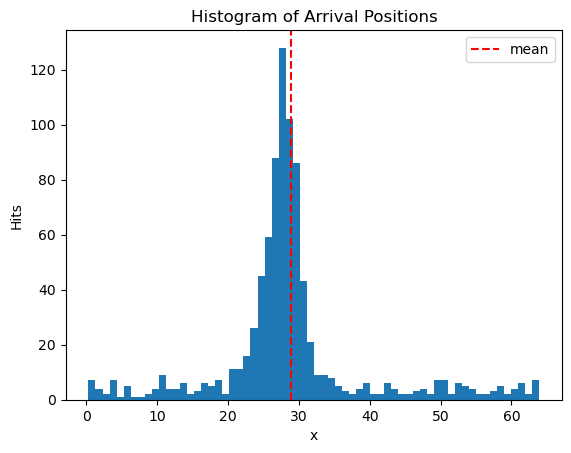

In [1]:
# Part 1: your work here
import numpy as np
import matplotlib.pyplot as plt

x = np.genfromtxt('acm18.csv', delimiter = ',', skip_header = 1)

N = len(x)
n_x0 = x.mean()
n_sig = x.std()/(N)**.5

plt.hist(x, bins = 64)
plt.axvline(n_x0, c = 'r', label = 'mean', ls = '--')

plt.title('Histogram of Arrival Positions');plt.xlabel('x');plt.ylabel('Hits');plt.legend()

print(f"naive estimator: x0 = {n_x0:.2f} ± {n_sig:.2f}")

**ANSWER (a few sentences):**

Considering that this data is a Moffat profile with a background it is clear that my data is biased. Based on the histogram I believe that my simple mean data point has been pulled by the bias in the possitive direction and this is effected by the true means relation to the center of the range of measured points. The x values range from 0 to 64 and the background is placed uniformly accross all points. Through observing the histogram I can see that $\hat{x}_0 $ is not centered over the middle of this range. This means that my sample mean is biased to be greater than the true value since there are more background points above the moffat distribution than bellow it.

## Part 2: Estimators you can defend (40%)

Now do it properly. Estimate $x_0$ **three more ways** and compare:

1. **The median** of the photon positions. Robust, simple, but is it unbiased here, and
   what is its variance? (You may answer the variance question empirically in Part 3.)
2. **A sigma-clipped mean**: iteratively remove photons far from the current estimate,
   re-estimate, repeat until it converges. Be explicit about your clipping threshold and
   why you chose it.
3. **Maximum likelihood on the mixture model.** Each photon is background with probability
   $f_{\rm bg}$, or from the star otherwise, so the probability density for a single photon at
   position $x$ is

   $$p(x \mid x_0, f_{\rm bg}) \;=\; \frac{f_{\rm bg}}{64} \;+\; (1 - f_{\rm bg})\,
   \frac{\Gamma(\beta)}{r_0\sqrt{\pi}\,\Gamma(\beta - \tfrac{1}{2})}
   \left[1 + \left(\frac{x - x_0}{r_0}\right)^2\right]^{-\beta}$$

   with $\beta = 2.5$ and $r_0 = 4$ px. Maximize $\sum_i \ln p(x_i \mid x_0, f_{\rm bg})$ over
   both parameters (see Ivezić, Connolly, VanderPlas & Gray, §4.2, for the machinery; this
   is the same likelihood game with different symbols). Get uncertainties from the curvature
   of the log-likelihood at its peak (the observed information), and say so.

Then compute the **Cramér–Rao bound**: the smallest variance any unbiased estimator of $x_0$
can achieve given your $N$ photons. The per-photon Fisher information
$I(x_0) = \int \frac{1}{p}\left(\frac{\partial p}{\partial x_0}\right)^2 dx$ is yours to
evaluate (numerically over the window is fine) and the bound is
$\sigma_{x_0} \geq 1/\sqrt{N\,I}$. Treat both parameters as unknown: the honest bound comes
from inverting the $2\times 2$ Fisher matrix, not the $x_0$ term alone. How close does each
of your four estimators get?

(Two technicalities you may use without proof: photons landing outside the window were lost,
but for your $x_0$ the lost fraction is negligible, and checking that claim makes a fine
Part 3 sensitivity test. And for simulating: a 1-D Moffat with exponent $\beta$ is a
Student-$t$ distribution with $\nu = 2\beta - 1$ degrees of freedom, scaled by
$r_0/\sqrt{\nu}$.)

Commit to a **final answer**, one $x_0 \pm \sigma$ and $f_{\rm bg} \pm \sigma$ you'd put in
a paper, and justify the choice. State clearly how you estimated your uncertainties and why
you believe them. Remember the 3× rule from the header.

Median estimator: x0 = 27.87 ± 0.36


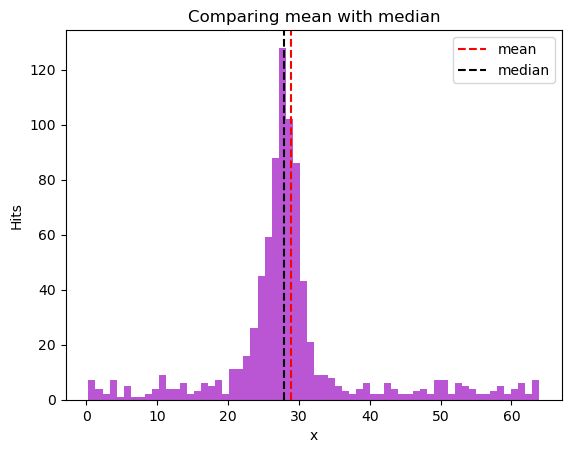

In [2]:
# Part 2: your work here
'''The Median'''
m_x0 = np.median(x)
m_sig = x.std()/(N)**.5

plt.hist(x, bins = 64, color = 'mediumorchid')
plt.axvline(n_x0, c = 'r', label = 'mean', ls = '--')
plt.axvline(m_x0, c = 'k', label = 'median', ls = '--')
plt.title('Comparing mean with median');plt.xlabel('x');plt.ylabel('Hits');plt.legend()

print(f"Median estimator: x0 = {m_x0:.2f} ± {m_sig:.2f}")


The median is more robust than the mean because it is no longer as biased by the extra background points when compared to the mean. The bias is not entirely gone because the median is just the center of the entire dataset not the center of specifically the moffat distribution. While robust than the mean this is not the best estimator in this lab.

The number of bins used in every histogram this lab is 64 bins from [0,64]. This ensures that every bin corresponds to one pixel on the 1D array.

Sigma Clipped mean: x0 = 27.67 ± 0.09
sigma clipped fbg = 0.22


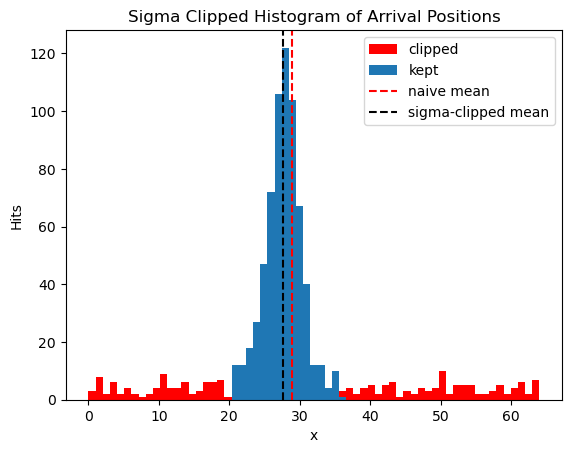

In [3]:
''' A sigma-clipped mean'''
def sigma_clip_mask(x, k=3.0, max_iter = 100):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        mean = x[mask].mean()
        sigma = x[mask].std()
        new_mask = np.abs(x-mean) < k * sigma
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    return mask
        
mask = sigma_clip_mask(x)

sc_x0 = x[mask].mean()
sc_sig = x[mask].std()/np.sqrt(N)
sc_fb = len(x[~mask])/len(x)

bins = np.linspace(0,64,64)
plt.hist(x,bins =bins, color = 'red', label = 'clipped')
plt.hist(x[mask], bins = bins, label = 'kept')
plt.axvline(n_x0, c = 'r', label = 'naive mean', ls = '--')
plt.axvline(sc_x0, c = 'k', label = 'sigma-clipped mean', ls = '--')

plt.title('Sigma Clipped Histogram of Arrival Positions');plt.xlabel('x');plt.ylabel('Hits');plt.legend()

print(f"Sigma Clipped mean: x0 = {sc_x0:.2f} ± {sc_sig:.2f}")
print(f'sigma clipped fbg = {sc_fb:.2f}')

For the Sigma Clipping model I choose to clip on 3 sigma. This bound ensures that I am keeping 98% of the data within the Moffat distribution. This cut should reduce the bias from the background and allow for a estimation much closer to the true values than the previous models.

maximum likelihood mean: x0 = 27.74 ± 0.10
Background fraction = 0.28 ± 0.02


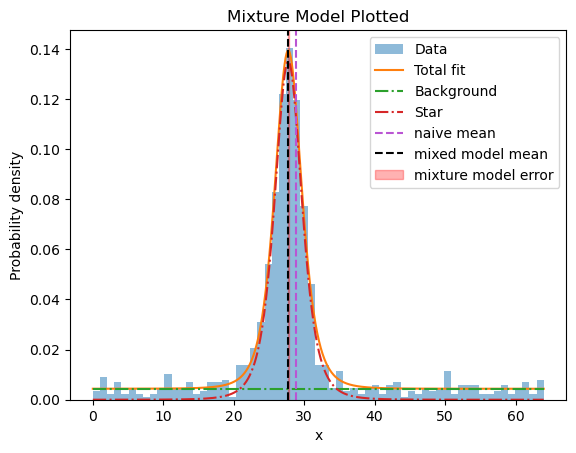

In [4]:
'''Maximum likelyhood on mixture model'''
from scipy.optimize import minimize
from scipy.stats import norm
from scipy.special import gamma as g

def neg_log_likelihood(theta, x):
    b = 2.5
    r0 = 4
    x0,fbg = theta
    model = (fbg/64) + ((1-fbg)*g(b)/(r0*np.sqrt(np.pi)*g(b-.5)))*(1+((x-x0)/r0)**2)**-b
    return -np.sum(np.log(model))

theta0 = [sc_x0, sc_fb]
result = minimize(neg_log_likelihood, theta0, args=(x), method='Nelder-Mead')
mm_x0,mm_fbg = result.x

def hessian(func, theta, x, eps=1e-5):
    n = len(theta)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            di = np.zeros(n)
            dj = np.zeros(n)
            di[i] = eps
            dj[j] = eps

            H[i,j] = (func(theta + di + dj, x) - func(theta + di - dj, x) - func(theta - di + dj, x) + func(theta - di - dj, x))/(4*eps**2)
    return H

H = hessian(neg_log_likelihood, result.x, x)

cov = np.linalg.inv(H)

mm_x0_sig  = np.sqrt(cov[0,0])
mm_fbg_sig = np.sqrt(cov[1,1])

xx = np.linspace(0, 64, 1000)

b = 2.5
r0 = 4

moffat = (g(b)/(r0*np.sqrt(np.pi)*g(b-0.5)) * (1 + ((xx-mm_x0)/r0)**2)**(-b))

bg = np.ones_like(xx)/64

model = mm_fbg*bg + (1-mm_fbg)*moffat

plt.hist(x, bins=bins, density=True,
         alpha=0.5, label='Data')

plt.plot(xx, model, label='Total fit')
plt.plot(xx, mm_fbg*bg, '-.', label='Background')
plt.plot(xx, (1-mm_fbg)*moffat, '-.', label='Star')

plt.axvline(n_x0, c = 'mediumorchid', label = 'naive mean', ls = '--')
plt.axvline(mm_x0, c = 'k', label = 'mixed model mean', ls = '--')
plt.axvspan((mm_x0-mm_x0_sig), mm_x0+mm_x0_sig, color='red', alpha=0.3, label='mixture model error')

plt.title('Mixture Model Plotted');plt.xlabel('x');plt.ylabel('Probability density');plt.legend()

print(f"maximum likelihood mean: x0 = {mm_x0:.2f} ± {mm_x0_sig:.2f}\nBackground fraction = {mm_fbg:.2f} ± {mm_fbg_sig:.2f}")

In [5]:
'''Cramer-Rao'''
from scipy.integrate import quad

def p(x,x0,fbg):
    t_moffat = (g(b)/(r0*np.sqrt(np.pi)*g(b-0.5)) * (1 + ((x-x0)/r0)**2)**(-b))
    return fbg/64 + (1-fbg)*t_moffat
def dp_dx0(x,x0,fbg):
    A = (g(b)/(r0*np.sqrt(np.pi)*g(b-0.5)))
    u = 1 + ((x-x0)/r0)**2
    return ((1-fbg)*2*A*b*(x-x0)/r0**2)*u**(-b-1)


def I_x0(x0, fbg):
    integrand = lambda x: (
        dp_dx0(x, x0, fbg)**2
        / p(x, x0, fbg)
    )
    I, err = quad(integrand, 0, 64)
    return I
I = I_x0(mm_x0,mm_fbg)
n = len(x)
sig_cr = 1/np.sqrt(n*I) #This is just the lower bound, need to evaluate the 2x2 matrix to get honest bound

print(f'Cramer-Rao: {sig_cr:.2f}')

Cramer-Rao: 0.10


When comparing to Cramer-Rao(CR), my naive model and median estimator are the farthest off with error 3.6x CR. Next closest was the sigma clipping which is only .01 less than CR meaning that this error is slightly underestimated. Finally my Mixture model uncertainty is exactly CR at 2 significant figures.

**FINAL ANSWER:** $x_0 = $ _27.74_ $\pm$ _0.10_ px , $f_{\rm bg} = $ _0.28_ $\pm$ _0.02_ , Cramér–Rao bound $\sigma_{x_0}^{\rm CRB} = $ _.10_ px

**Justification and uncertainty method (a short paragraph):**

The method that I used to determine my final values for $x_0$ and $f_{\rm bg}$ was the mixture model. This method provides the most robust fit where all data is taken into account but the bias from the background data does not end up affecting the reported $x_0$ value.
To determine the uncertainties, I computed a finite Hessian matrix around the maximum of the log-liklihood function. The diagonal element of the Hessian computes the second derivative of the function with respect to the predicted values which I approximate numerically. The inverse of the Hessian is the covariance matrix which has the variance of each of the predicted values on the diagonal element. The square root of that variance is the uncertainty that I report. I trust this method because these errors are calculated directly from the model used to create the predicted values. My confidence was further backed up when after computing the Cramér–Rao bound because it was equivalent to my computed error. The bounds I have selected the smallest reasonable bounds to expect from my specific data.

## Part 3: The verification plan, written first and then executed (35%)

This is the headline of this lab. **Before you run anything below, write the plan** (3a).
A verification plan you invent after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the Student-$t$ fact from
   Part 2 makes this easy) and confirm your estimator recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot their bias and their variance against the Cramér–Rao bound.
   This is *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time?
4. **Sensitivity**: what happens to your $\hat{x}_0$ if $\beta$ or $r_0$ are slightly wrong,
   or if the lost-photon fraction isn't negligible after all?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

1. I will create a dataset that has a $f_{\rm bg}$ = .25, N = 900, and $x_0$ = 40 by adding $f_{\rm bg}$/64 to a student-$t$ distrubution described in part 2. I will then run the mixture model on this data to see if it's error bounds retain the true values. This Check will fail if my returned bounds on this toy data do not include the known truth.
2. I will write a simulation that will take my toy model and for n many iterations change the rng of the noise and estimate the mean $x_0$ values and its variance for each of my four estimators. This data will then be processed in a pandas dataframe where i can produce tables and a scatter plot showing how the variance and bias of each estimator compares to the CR bound. I will evaluate the CR bound by taking the inverse of the 2X2 fisher matrix to make sure I am using the most acurate value and provide an opportunity to check my earlier CR bound. Failure in this case would be if my choosen micture model estimator shows to have significant bias when compared to cramer-rao and if the honest Cramer-rao diverges from my earlier reported value.
3. To check the coverage of each estimator I can use my dataframe to score each trial if the estimator included the true values. An estimator fails this check if the percent of trials that included the true parameters is less than 68%
4.  To check the sensitivity I will change the $\beta$ and $r_0$ values fed into the simulated data and then test with my minimization model to see if it can still retrieve the true value. The failure mode is if the model can no longer retrieve the true values

In [6]:
# Part 3b: execute the plan here
'''Closure'''
#creating a toy model
from scipy.stats import t
import pandas as pd

# --------------------------------------------------
# Toy model generator
# --------------------------------------------------
Tx0 = 40
Tfbg = .25
def simulate_data(seed,N=900,fbg=0.25,x0=40,b=2.5, r0=4):
    rng = np.random.default_rng(seed)
    nu = 2*b - 1
    scale = r0 / np.sqrt(nu)
    # Random number of background photons
    N_bg = rng.binomial(N, fbg)
    N_star = N - N_bg
    # Background photons
    x_bg = rng.uniform(0, 64, N_bg)
    # Stellar photons
    x_star = t.rvs(
        df=nu,
        loc=x0,
        scale=scale,
        size=N_star,
        random_state=rng
    )
    # Reject photons outside window
    x_star = x_star[(x_star >= 0) & (x_star <= 64)]
    while len(x_star) < N_star:
        needed = N_star - len(x_star)
        new = t.rvs(
            df=nu,
            loc=x0,
            scale=scale,
            size=needed,
            random_state=rng
        )
        new = new[(new >= 0) & (new <= 64)]
        x_star = np.concatenate([x_star, new])
    x = np.concatenate([x_bg, x_star])
    rng.shuffle(x)
    return x
tx = simulate_data(9152026)
#estimate parameters
ttheta0 = [38, .24]
tresult = minimize(neg_log_likelihood, ttheta0, args=(tx,), method='Nelder-Mead')
tmm_x0,tmm_fbg = tresult.x

tH = hessian(neg_log_likelihood, tresult.x, tx)

cov = np.linalg.inv(tH)

tmm_x0_sig  = np.sqrt(cov[0,0])
tmm_fbg_sig = np.sqrt(cov[1,1])

print(f"maximum likelihood mean: x0 = {tmm_x0:.2f} ± {tmm_x0_sig:.2f}\nBackground fraction = {tmm_fbg:.2f} ± {tmm_fbg_sig:.2f}\nTrue values: x0 = {Tx0}, fbg = {Tfbg}")

maximum likelihood mean: x0 = 40.08 ± 0.10
Background fraction = 0.28 ± 0.02
True values: x0 = 40, fbg = 0.25


In [7]:
'''Bias and Efficiency'''
def mean_est(x):
    return np.mean(x)
def sigma_clip_est(x):
    mask = sigma_clip_mask(x)
    return np.mean(x[mask])
def median_est(x):
    return np.median(x)
def mle_est(x):
    theta0 = [38, .24]
    tresult = minimize(neg_log_likelihood, theta0, args=(x,), method='Nelder-Mead')
    mm_x0,mm_fbg = tresult.x
    return mm_x0
def estimate_all(x):
    return {
        "mean"         : mean_est(x),
        "median"       : median_est(x),
        "sigma_clip"   : sigma_clip_est(x),
        "mle"          : mle_est(x)
    }
n_mc = 1000
results = []
for seed in range(n_mc):
    rng = np.random.default_rng(seed)
    x = simulate_data(rng,N=900,fbg=0.25,x0=40)

    row = estimate_all(x)

    row["seed"] = seed

    results.append(row)

df = pd.DataFrame(results)


In [8]:
L = ['mean','median','sigma_clip','mle']

data = []
for i in L:
    est = i
    bia = np.mean(df[i]) - Tx0
    var = np.var(df[i])
    d = {'Estimator':est,'bias':bia, 'variance':var}
    data.append(d)

fdf = pd.DataFrame(data)

In [9]:
def dp_dfbg(x,x0):
    A = (g(b)/(r0*np.sqrt(np.pi)*g(b-0.5)))
    M = A*(1+((x-x0)/r0)**2)**(-b)
    return 1/64 - M

def I_matrix(x0, fbg):

    # F00
    F00, _ = quad(
        lambda x:
        dp_dx0(x, x0, fbg)**2
        / p(x, x0, fbg),
        0, 64
    )
    # F01
    F01, _ = quad(
        lambda x:
        dp_dx0(x, x0, fbg)
        * dp_dfbg(x, x0)
        / p(x, x0, fbg),
        0, 64
    )
    # F11
    F11, _ = quad(
        lambda x:
        dp_dfbg(x, x0)**2
        / p(x, x0, fbg),
        0, 64
    )
    return np.array([
        [F00, F01],
        [F01, F11]
    ])
F = I_matrix(40,0.25)
cov_CR = np.linalg.inv(len(x)*F)
var_CR = cov_CR[0,0]

print(f'Honest CR sigma = {np.sqrt(var_CR):.2f}\nReprted CR sigma = {sig_cr:.2f}')

fdf['efficiency'] = cov_CR[0,0] / fdf['variance']
fdf.loc[len(fdf)] = ["CR Bound", 0,var_CR,1]
fdf

Honest CR sigma = 0.10
Reprted CR sigma = 0.10


,Estimator,bias,variance,efficiency
0,mean,-2.012458,0.117183,0.079672
1,median,-0.220863,0.012886,0.724522
2,sigma_clip,-0.003934,0.013597,0.686628
3,mle,-0.000847,0.009758,0.956741
4,CR Bound,0.000000,0.009336,1.000000


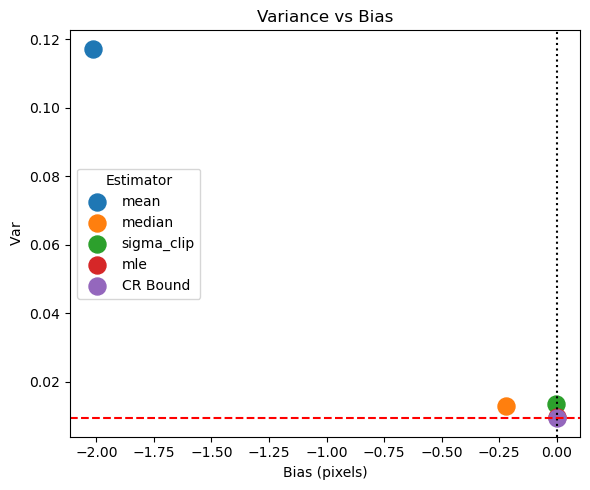

In [10]:
plt.figure(figsize=(6,5))

for _, row in fdf.iterrows():

    plt.scatter(
        row["bias"],
        row["variance"],
        s=150,
        label=row["Estimator"]
    )

plt.axvline(0,color='black',ls=':')
plt.axhline(var_CR,color='red',ls='--')

plt.xlabel("Bias (pixels)")
plt.ylabel(r"$\mathrm{Var}$")
plt.title('Variance vs Bias')

plt.legend(title="Estimator")
plt.tight_layout()

In [12]:
'''Coverage'''

coverage = {}
for est in ["mean", "median", "sigma_clip", "mle"]:

    covered = np.abs(df[est] - Tx0) < np.std(df[est])

    coverage[est] = covered.mean()

print(pd.Series(coverage))

mean          0.000
median        0.158
sigma_clip    0.677
mle           0.683
dtype: float64


In [13]:
'''Sensitivity'''

tx = simulate_data(9152026,b=5,r0=4)
#estimate parameters
ttheta0 = [38, .24]
tresult = minimize(neg_log_likelihood, ttheta0, args=(tx,), method='Nelder-Mead')
tmm_x0,tmm_fbg = tresult.x

tH = hessian(neg_log_likelihood, tresult.x, tx)

cov = np.linalg.inv(tH)

tmm_x0_sig  = np.sqrt(cov[0,0])
tmm_fbg_sig = np.sqrt(cov[1,1])

tx = simulate_data(9152026,b=2.5,r0=8)
#estimate parameters
ttheta0 = [38, .24]
tresult = minimize(neg_log_likelihood, ttheta0, args=(tx,), method='Nelder-Mead')
tmm_x00,tmm_fbg0 = tresult.x

tH = hessian(neg_log_likelihood, tresult.x, tx)

cov = np.linalg.inv(tH)

tmm_x0_sig0  = np.sqrt(cov[0,0])
tmm_fbg_sig0 = np.sqrt(cov[1,1])
print(f"0maximum likelihood mean: x0 = {tmm_x00:.2f} ± {tmm_x0_sig0:.2f}\n0Background fraction = {tmm_fbg0:.2f} ± {tmm_fbg_sig0:.2f}")
print(f"1maximum likelihood mean: x0 = {tmm_x0:.2f} ± {tmm_x0_sig:.2f}\n1Background fraction = {tmm_fbg:.2f} ± {tmm_fbg_sig:.2f}\nTrue values: x0 = {Tx0}, fbg = {Tfbg}")

0maximum likelihood mean: x0 = 40.05 ± 0.15
0Background fraction = 0.44 ± 0.02
1maximum likelihood mean: x0 = 40.11 ± 0.08
1Background fraction = 0.23 ± 0.02
True values: x0 = 40, fbg = 0.25


**WHAT THE CHECKS FOUND:**

#### closure

After running the closure check, the maximum likelyhood model(MLM) was able to return parameters with bounds that contained the true values. Therefore the model that I chose when reporting my final values has passed the closure test

#### Bias and Efficiency

The most illuminating result from this check was the table that shows how closely the miaximum likelihood model approached the CR bound. This varified my chosen model and also demonstrated how poorly the naive fit and median models work. The other result from my test is that the approximated CR bound from computing the integral closely matches the honest CR bound derived from the fisher matrix. 

#### Coverage

The surprising result from the coverage test is that only the MLM contained the true value at least 68% of the time. This verified that the MLM estimator performs the best out of all four methods seen in this lab and further verifies the results reported in part 2.

#### Sensitivity

The interesting result after this test is that the mean estimate from MLM model is resistant to changes in $\beta$ and $r_0$. The fractional background is not resistant to changes of $r_0$ in my test doubling $r_0$ to 8 while holding all else constant caused the background fraction to be inflated far away from the true value. This means that my model fails to be sensitive to changes in $r_0$ while still being sensitive to changes in $\beta$.


## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true. (Your verification plan lives in Part 3 this week; it earned a
promotion. If an AI wrote any of it, that belongs here too.)

**AI-USE APPENDIX:**

I was unsure if I had written my sigma clipping code correctly so I asked copilot to check it for me. It cought a simple error in my code that I then fixed on my own.

I asked co-pilot how to determine the uncertainties from the logliklelihood function. The method it recomended was to evaluate a numerical Hessian whose inverse would be the covariance matrix with the uncertainties. It also recomended a simpler method using scipy where you change the minimization method from Nelder-Mead to L-BFGS-B. After investigating both options I decided that numerically calculating the hessian is closer to what the homework is asking me to do. 

I was having trouble starting the Cramer-Rao calculation so I asked copilot to explain the process and help get me started. After reading its analysis I relized that the p is p(x) and we are given p(x|x0, fb). With that knowledge I then wrote my own code that calculated I(x0) using copilot to help be fill any gaps in my python knowledge like how to compute an integral. I cought the AI make a typo when computing the fisher matrix, the AI kept adding "funcsx * funcsx" into the integrand which were undefined values with no real meaning. After arguing for a bit I had it redo the entire analysis and assemble the matrix by computing each value individually instead of a for loop. This worked.

The cramer rao I computed was .001 larger than the error from my hessian so I asked copilot whats up with that. It helped me find a minor error in the code and then I relized that a >1% discrepancy makes since when you take into account 

I had copilot make my simulated data during the verification plan. And then create the monte carlo simulation. I took the simulation from copilot and adopted it to better match my neads. The pandas code is my own but the framework for how to set up the simulation came from AI.

All of the text in this lab was written by myself.